In [1]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from multiprocessing import Pool, cpu_count
import itertools
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.input_statistics.matrix_pool_manager import (
    MatrixPoolManager,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix.field_vector import FieldVector
from random_matrix.scattering_matrix.scattering_matrix import ScatteringMatrix
import cupy as cp
import math
from tqdm import tqdm

In [2]:
base_path = "/mnt/raid/rmt/data"
simulation_name = "memory_effect_rectangular"
pm = MatrixPoolManager(simulation_name, base_path)
pm.load_single_pool_S()
# pm.populate_single_pool(700, False, "S", False, None, True, True)

In [3]:
len(pm.single_pool_S)

700

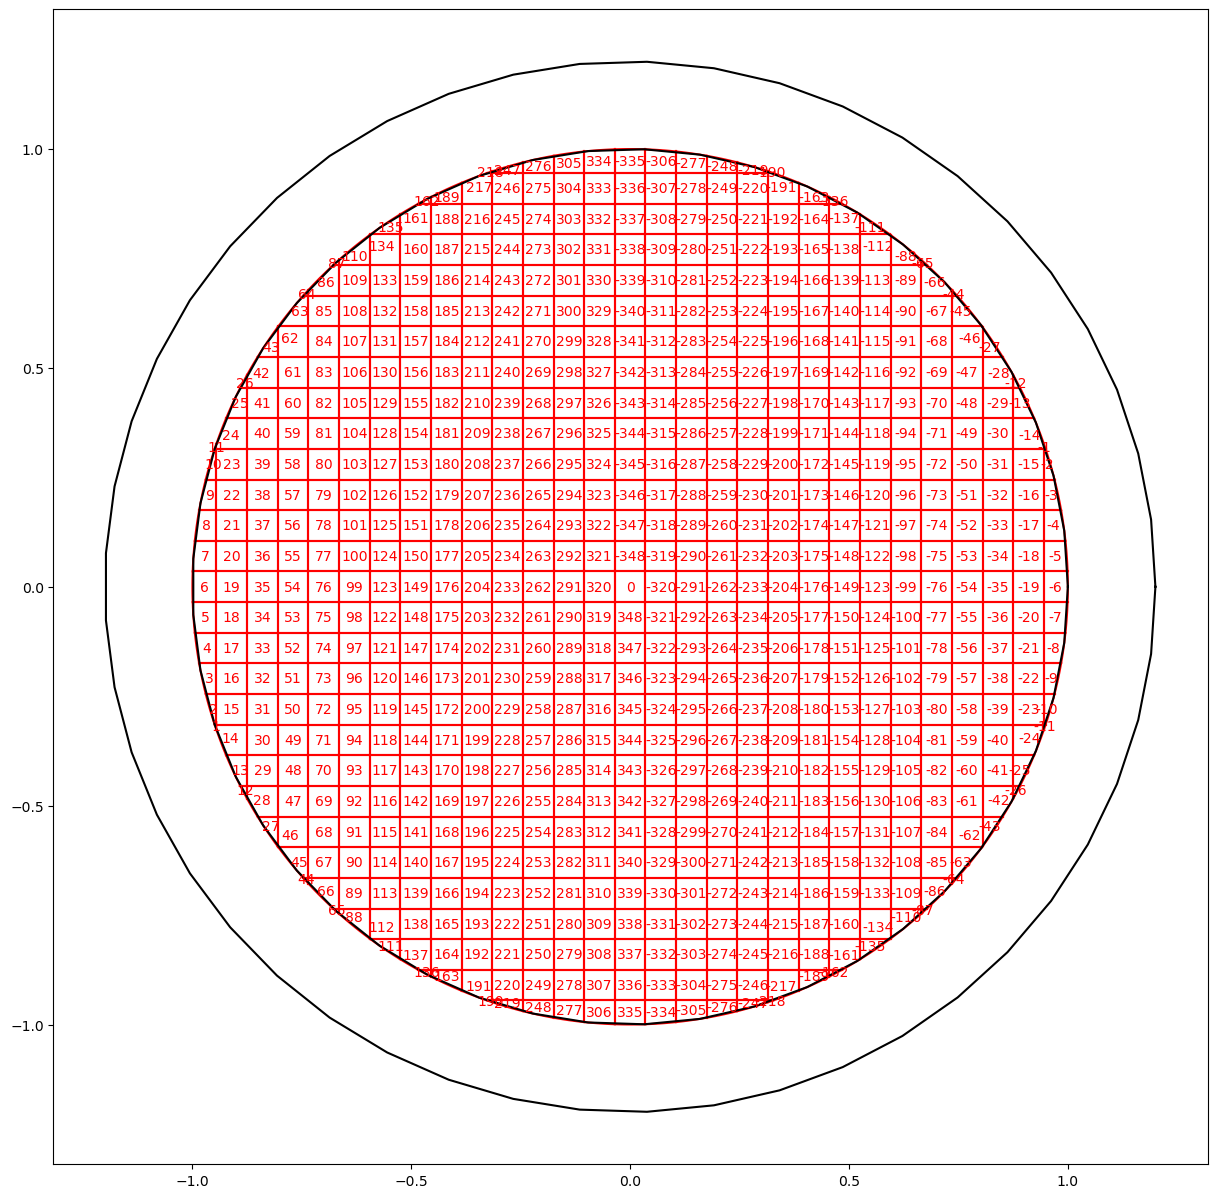

In [4]:
my_grid = pm.mode_grid
my_grid.plot(show_indices=True, figsize=(15, 15))
fv = FieldVector(my_grid)
sm = ScatteringMatrix(my_grid)

In [5]:
# Work out the spacing. Manual for now
central = my_grid.by_index(0)
off = my_grid.by_index(-320)
spacing = (off.center - central.center)[0]
print(spacing)

0.07


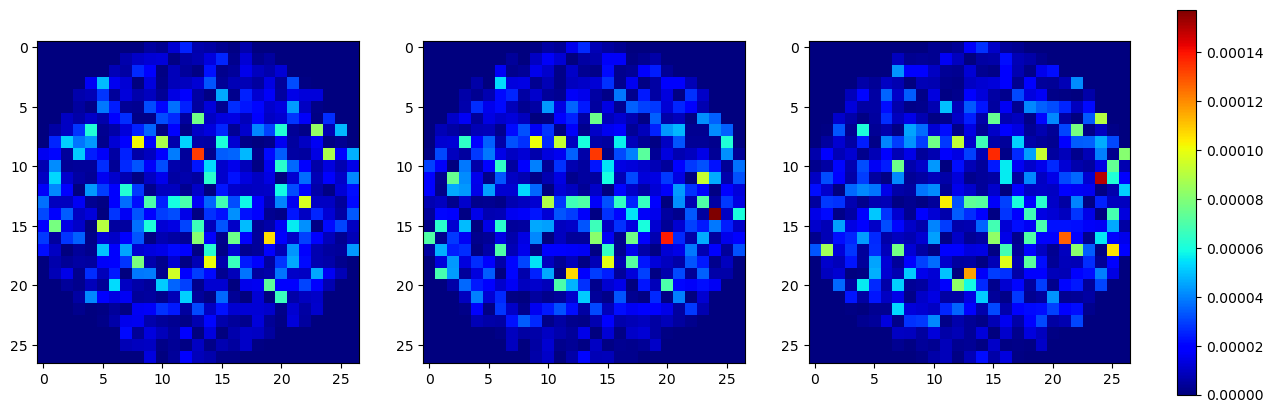

In [6]:
incident_indices = [0, -320, -291]
plot_data = [
    fv.get_2d_representation(
        sm.get_column_intensity(
            matrix_utils.get_block(pm.single_pool_S[0], "t"),
            incident_index,
            "p",
        )
    )
    for incident_index in incident_indices
]
fv.plot_imshows(plot_data)

In [7]:
def roll_with_zeros(arr, shift_y=0, shift_x=0):
    """
    Shift a 2D array like np.roll but fill edges with 0 instead of wrapping.

    Positive shift_y: shift down
    Positive shift_x: shift right
    """
    result = np.zeros_like(arr)

    # source slice
    y_src_start = max(-shift_y, 0)
    y_src_end = arr.shape[0] - max(shift_y, 0)
    x_src_start = max(-shift_x, 0)
    x_src_end = arr.shape[1] - max(shift_x, 0)

    # destination slice
    y_dst_start = max(shift_y, 0)
    y_dst_end = arr.shape[0] - max(-shift_y, 0)
    x_dst_start = max(shift_x, 0)
    x_dst_end = arr.shape[1] - max(-shift_x, 0)

    # copy the overlapping region
    result[y_dst_start:y_dst_end, x_dst_start:x_dst_end] = arr[
        y_src_start:y_src_end, x_src_start:x_src_end
    ]

    return result

In [8]:
polarization_keys = ["pp", "ps", "sp", "ss"]

incident_indices = [
    mode.index for mode in my_grid.propagating_modes_list if not mode.is_edge
]

# Extract scattering matrix blocks
t = matrix_utils.get_block(pm.single_pool_S[0], "t")
t_pp = sm.get_pp(t)
t_ps = sm.get_ps(t)
t_sp = sm.get_sp(t)
t_ss = sm.get_ss(t)
mask = fv.get_2d_representation(sm.get_column(t_pp, 0)).real != 0

# Prepare data dictionaries
data = {
    "pp": {idx: sm.get_column(t_pp, idx) for idx in incident_indices},
    "ps": {idx: sm.get_column(t_ps, idx) for idx in incident_indices},
    "sp": {idx: sm.get_column(t_sp, idx) for idx in incident_indices},
    "ss": {idx: sm.get_column(t_ss, idx) for idx in incident_indices},
}

reference_data = {key: data[key][0] for key in polarization_keys}
reference_auto_corr = {
    key: np.sum(reference_data[key] * np.conj(reference_data[key]))
    for key in polarization_keys
}

# Correlation map setup
correlation_map_size = 27
spacing = 0.07
center_offset = correlation_map_size // 2


# Worker function for multiprocessing
def process_index(index):
    local_corr = {
        (ref_key, new_key): np.zeros(
            (correlation_map_size, correlation_map_size), dtype=np.complex128
        )
        for ref_key, new_key in itertools.product(polarization_keys, repeat=2)
    }

    mode = my_grid.by_index(int(index))
    center = mode.center
    dx, dy = np.rint(center / spacing).astype(int)

    for ref_key, new_key in itertools.product(polarization_keys, repeat=2):
        new_vector = data[new_key][index]
        ref_vector = reference_data[ref_key]

        # Convert to 2D representation
        new_2d = fv.get_2d_representation(new_vector)
        ref_2d = fv.get_2d_representation(ref_vector)

        # Shift new data with zeros at edges
        new_2d_shifted = roll_with_zeros(new_2d, dy, -dx)
        mask_shifted = roll_with_zeros(mask, dy, -dx)
        valid = mask & mask_shifted

        # Compute normalized cross-correlation
        new_auto = np.sum(
            new_2d_shifted[valid] * np.conj(new_2d_shifted[valid])
        )
        ref_auto = np.sum(ref_2d[valid] * np.conj(ref_2d[valid]))
        cross_corr = np.sum(ref_2d[valid] * np.conj(new_2d_shifted[valid]))
        normalized = cross_corr / np.sqrt(new_auto * ref_auto)

        # Place value in correlation map
        i = dx + center_offset
        j = -dy + center_offset
        if 0 <= i < correlation_map_size and 0 <= j < correlation_map_size:
            local_corr[(ref_key, new_key)][i, j] = normalized

    return local_corr


# Run with multiprocessing
num_processes = min(cpu_count(), len(incident_indices))
with Pool(num_processes) as pool:
    results = list(
        tqdm(
            pool.imap(process_index, incident_indices),
            total=len(incident_indices),
        )
    )

# Merge results
correlation_data = {
    key: sum(result[key] for result in results) for key in results[0].keys()
}

100%|██████████| 585/585 [00:21<00:00, 27.59it/s]


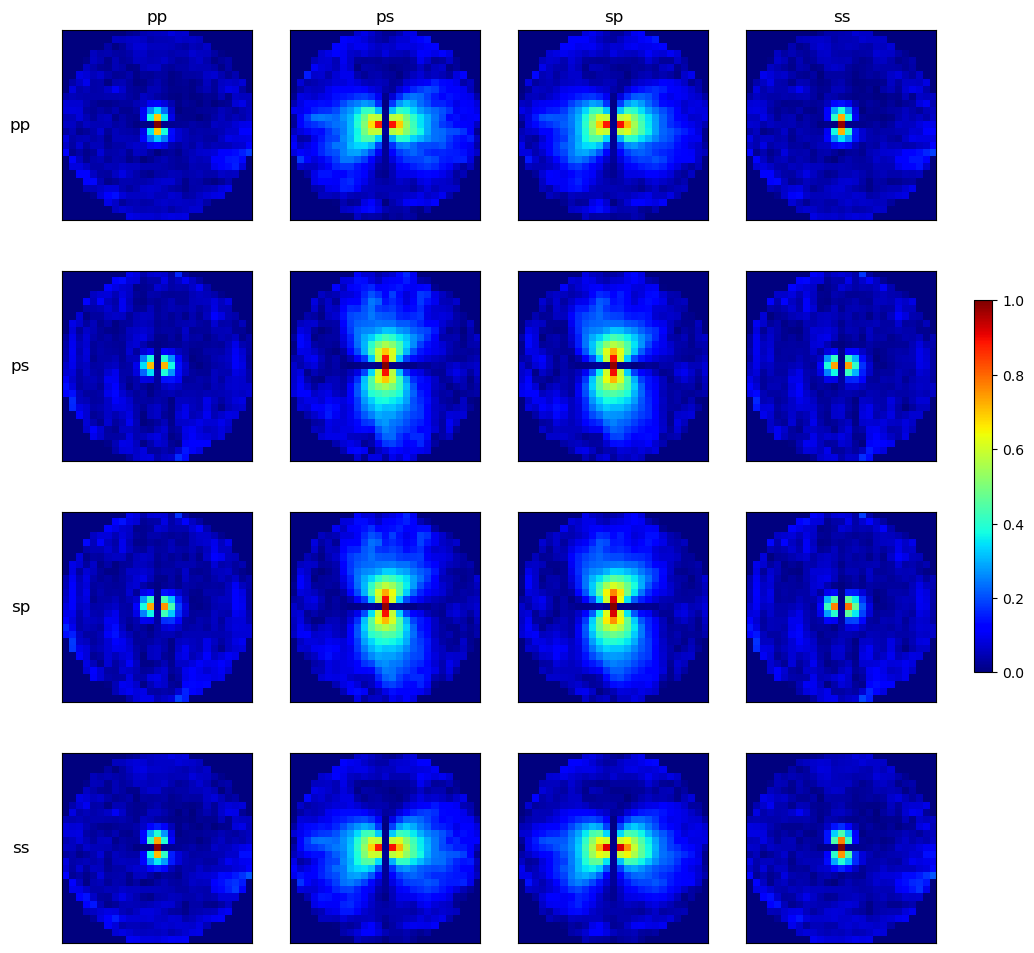

In [9]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

# Compute global normalization
all_values = np.array(
    [
        np.abs(correlation_data[key])
        for key in itertools.product(polarization_keys, repeat=2)
    ]
)
vmin, vmax = all_values.min(), all_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet
scm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
scm.set_array([])

for i, ref_key in enumerate(polarization_keys):
    for j, new_key in enumerate(polarization_keys):
        ax = axs[i, j]
        im = ax.imshow(
            np.abs(correlation_data[(ref_key, new_key)]), norm=norm, cmap=cmap
        )
        ax.set_xticks([])
        ax.set_yticks([])

        # Only label the top row with new_key
        if i == 0:
            ax.set_title(new_key, fontsize=12)
        # Only label the left column with ref_key
        if j == 0:
            ax.set_ylabel(
                ref_key, fontsize=12, rotation=0, labelpad=30, va="center"
            )

# Add single colorbar
fig.colorbar(scm, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)

In [ ]:
master_corr = {
    (ref_inc, new_inc): np.zeros(
        (3, correlation_map_size, correlation_map_size), dtype=np.float64
    )
    for ref_inc, new_inc in itertools.product(["p", "s"], repeat=2)
}
local_corrs = []

for S_index in range(len(pm.single_pool_S)):

    polarization_keys = ["pp", "ps", "sp", "ss"]
    incident_indices = [
        mode.index
        for mode in my_grid.propagating_modes_list
        if not mode.is_edge
    ]

    # Extract scattering matrix blocks
    t = matrix_utils.get_block(pm.single_pool_S[S_index], "t")
    t_pp = sm.get_pp(t)
    t_ps = sm.get_ps(t)
    t_sp = sm.get_sp(t)
    t_ss = sm.get_ss(t)
    mask = fv.get_2d_representation(sm.get_column(t_pp, 0)).real != 0

    # Prepare data dictionaries
    data = {
        "pp": {idx: sm.get_column(t_pp, idx) for idx in incident_indices},
        "ps": {idx: sm.get_column(t_ps, idx) for idx in incident_indices},
        "sp": {idx: sm.get_column(t_sp, idx) for idx in incident_indices},
        "ss": {idx: sm.get_column(t_ss, idx) for idx in incident_indices},
    }

    # Compute reference data (incident polarization only, averaged over outputs)
    reference_data = {}
    for ref_inc in ["p", "s"]:
        # sum of squared magnitudes across output polarizations
        combined = np.zeros_like(
            next(iter(data["pp"].values())), dtype=np.float64
        )
        for out_pol in ["p", "s"]:
            key = out_pol + ref_inc  # output + incident
            combined += np.abs(data[key][0]) ** 2
        reference_data[ref_inc] = combined

    # Correlation map setup
    correlation_map_size = 27
    spacing = 0.07
    center_offset = correlation_map_size // 2

    def process_index_avg(index):
        """Compute correlations for one incident index, averaging over output polarizations."""
        local_corr = {
            (ref_inc, new_inc): np.zeros(
                (3, correlation_map_size, correlation_map_size),
                dtype=np.float64,
            )
            for ref_inc, new_inc in itertools.product(["p", "s"], repeat=2)
        }

        mode = my_grid.by_index(int(index))
        center = mode.center
        dx, dy = np.rint(center / spacing).astype(int)

        for ref_inc, new_inc in itertools.product(["p", "s"], repeat=2):
            # Sum intensities over output polarizations
            new_data = np.zeros_like(
                next(iter(data["pp"].values())), dtype=np.float64
            )
            for out_pol in ["p", "s"]:
                key = out_pol + new_inc
                new_data += np.abs(data[key][index]) ** 2

            ref_vector = reference_data[ref_inc]

            # Convert to 2D representation
            new_2d = fv.get_2d_representation(new_data)
            ref_2d = fv.get_2d_representation(ref_vector)

            # Shift new data with zeros at edges
            new_2d_shifted = roll_with_zeros(new_2d, dy, -dx)
            mask_shifted = roll_with_zeros(mask, dy, -dx)
            valid = mask & mask_shifted

            # Compute normalized cross-correlation
            new_auto = np.sum(new_2d_shifted[valid] ** 2)
            ref_auto = np.sum(ref_2d[valid] ** 2)
            cross_corr = np.sum(ref_2d[valid] * new_2d_shifted[valid])
            # normalized = cross_corr / np.sqrt(new_auto * ref_auto)

            # Place value in correlation map
            i = dx + center_offset
            j = -dy + center_offset
            if 0 <= i < correlation_map_size and 0 <= j < correlation_map_size:
                local_corr[(ref_inc, new_inc)][0, i, j] = cross_corr
                local_corr[(ref_inc, new_inc)][1, i, j] = new_auto
                local_corr[(ref_inc, new_inc)][2, i, j] = ref_auto

        return local_corr

    # Run with multiprocessing
    num_processes = min(cpu_count(), len(incident_indices))
    with Pool(num_processes) as pool:
        results = list(
            tqdm(
                pool.imap(process_index_avg, incident_indices),
                total=len(incident_indices),
            )
        )

    local_corrs.append(results)
    # Merge results
    correlation_data = {
        key: sum(result[key] for result in results)
        for key in results[0].keys()
    }

100%|██████████| 585/585 [00:05<00:00, 101.60it/s]


In [69]:
cross_corr = {
    key: np.zeros((27, 27), dtype=np.complex128)
    for key in local_corrs[0][0].keys()
}
ref_auto = {
    key: np.zeros((27, 27), dtype=np.complex128)
    for key in local_corrs[0][0].keys()
}
new_auto = {
    key: np.zeros((27, 27), dtype=np.complex128)
    for key in local_corrs[0][0].keys()
}


# for S_index in range(len(pm.single_pool_S)):
for S_index in range(5):
    for key in local_corrs[0][0].keys():
        cross_corr[key] += sum(
            local_corrs[S_index][i][key][0]
            for i in range(len(local_corrs[S_index]))
        )
        ref_auto[key] += sum(
            local_corrs[S_index][i][key][2]
            for i in range(len(local_corrs[S_index]))
        )
        new_auto[key] += sum(
            local_corrs[S_index][i][key][1]
            for i in range(len(local_corrs[S_index]))
        )

In [70]:
normalized = {
    key: cross_corr[key] / np.sqrt(ref_auto[key] * new_auto[key])
    for key in local_corrs[0][0].keys()
}

/tmp/ipykernel_817622/3850730545.py:2: RuntimeWarning: invalid value encountered in divide
  key: cross_corr[key] / np.sqrt(ref_auto[key] * new_auto[key])


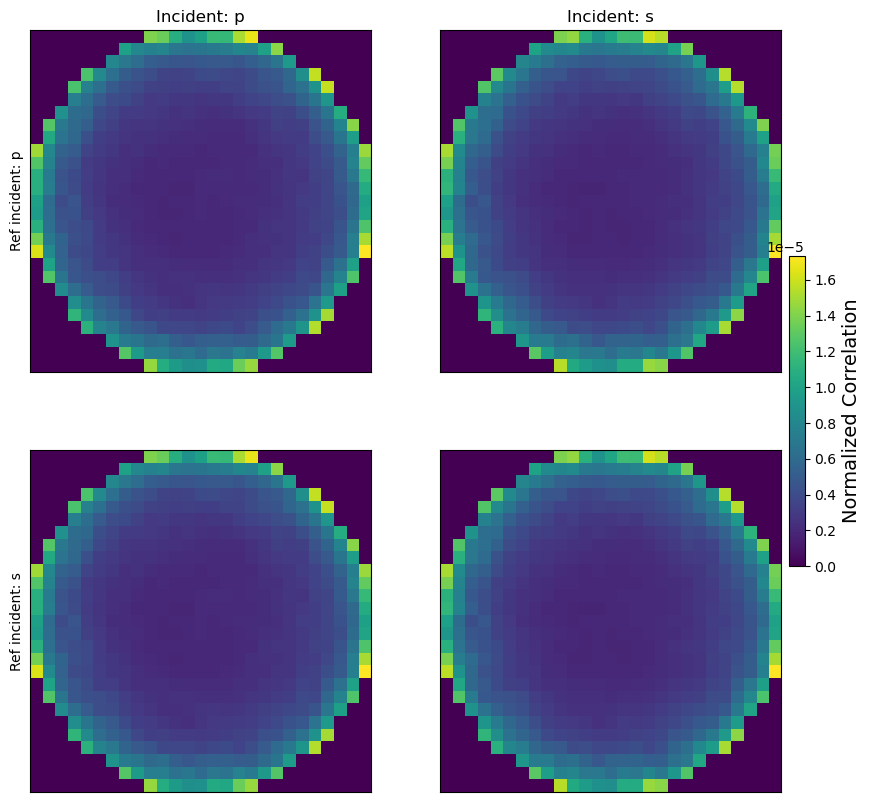

In [71]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# all_values = np.array([correlation_data[key] for key in correlation_data])
# vmin, vmax = all_values.min(), all_values.max()
# norm = plt.Normalize(vmin=vmin, vmax=vmax)
# cmap = plt.cm.jet

for row, ref_inc in enumerate(["p", "s"]):
    for col, new_inc in enumerate(["p", "s"]):
        ax = axs[row, col]
        im = ax.imshow(
            np.abs(new_auto[(ref_inc, new_inc)])
        )
        if row == 0:
            ax.set_title(f"Incident: {new_inc}")
        if col == 0:
            ax.set_ylabel(f"Ref incident: {ref_inc}")
        ax.set_xticks([])
        ax.set_yticks([])

# Single colorbar
cbar = fig.colorbar(
    im, ax=axs, orientation="vertical", fraction=0.02, pad=0.01
)
cbar.set_label("Normalized Correlation", fontsize=14)

In [ ]:
S = pm.single_pool_S[0]
matrix_utils.get_sub_block(S, "t", (0, 0), my_grid.propagating_indices)

In [ ]:
len(pm.single_pool_S)

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import shapely
from shapely.geometry import Point
from matplotlib import colors

# Example: get interior modes from your grid
interior_modes_list = [
    m for m in my_grid.propagating_modes_list if not m.is_edge
]
vertices_list = [m.vertices for m in interior_modes_list]
mode_indices = [m.index for m in interior_modes_list]  # store mode indices
num_interior_modes = len(interior_modes_list)

# Initialize values for coloring top plot
top_values = np.zeros(len(vertices_list))  # 0 = off, 1 = on
cmap = plt.cm.viridis
zero_color = cmap(0)  # background color for 0 values

# Setup figure with two axes: top = selector, bottom = data
fig = plt.figure(figsize=(6, 10))
ax_top = fig.add_axes([0.1, 0.55, 0.8, 0.4])
ax_bottom = fig.add_axes([0.1, 0.05, 0.8, 0.4])

ax_top.set_xlim(-1, 1)
ax_top.set_ylim(-1, 1)
ax_top.set_aspect("equal")

ax_bottom.set_xlim(ax_top.get_xlim())
ax_bottom.set_ylim(ax_top.get_ylim())
ax_bottom.set_aspect("equal")
ax_bottom.set_facecolor(zero_color)  # set background to 0 color

# Store polygon patches and centers for top plot
top_patches = []
centers = []
for verts in vertices_list:
    patch = Polygon(verts, facecolor=cmap(0), edgecolor="white", alpha=1)
    ax_top.add_patch(patch)
    top_patches.append(patch)
    verts_np = np.array(verts)
    centers.append(verts_np.mean(axis=0))

# Bottom plot: one patch per mode (same geometry)
bottom_patches = {}
for m, verts in zip(interior_modes_list, vertices_list):
    patch = Polygon(verts, facecolor=zero_color, edgecolor="white", alpha=1)
    ax_bottom.add_patch(patch)
    bottom_patches[m.index] = patch  # key = mode index

clicked_indices = []
arrow_artist_top = None
arrow_artist_bottom = None

# Precompute shapely polygons for faster point-in-polygon checks
mode_polygons = {m.index: shapely.Polygon(m.vertices) for m in interior_modes_list}


def compute_data_dict(mi, mj):
    """Compute a dictionary keyed by mode index: values for bottom plot"""
    dkij = mj.center - mi.center
    data_dict = {}
    J_ij = matrix_utils.get_sub_block(S, "t", (mi.index, mj.index), my_grid.propagating_indices)
    I_ij = np.abs(J_ij[0,0])**2 + np.abs(J_ij[1,0])**2

    for mu in interior_modes_list:
        u_center = mu.center
        v_center = u_center + dkij
        v_point = Point(v_center)
        found = 0

        for mv in interior_modes_list:
            if mode_polygons[mv.index].contains(v_point):
                J_uv = matrix_utils.get_sub_block(S, "t", (mu.index, mv.index), my_grid.propagating_indices)
                
                I_uv = np.abs(J_uv[0,0])**2 + np.abs(J_uv[1,0])**2
                found = I_ij * I_uv

                # found = np.abs(J_ij[0,0] * np.conj(J_uv[0,0]))
                
                break
        data_dict[mu.index] = found

    return data_dict


def update_bottom_plot(data_dict, arrow_coords=None):
    """Update bottom plot colors and optionally draw arrow"""
    if not data_dict:
        return

    vals = np.array(list(data_dict.values()))
    vmin = np.percentile(vals, 5)   # ignore lowest 5%
    vmax = np.percentile(vals, 95)  # ignore highest 5%
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    for idx, val in data_dict.items():
        if idx in bottom_patches:
            bottom_patches[idx].set_facecolor(cmap(norm(val)))

    # Draw arrow on bottom plot
    global arrow_artist_bottom
    if arrow_artist_bottom:
        arrow_artist_bottom.remove()
        arrow_artist_bottom = None

    if arrow_coords is not None:
        c1, c2 = arrow_coords
        arrow_artist_bottom = ax_bottom.arrow(
            c1[0],
            c1[1],
            c2[0] - c1[0],
            c2[1] - c1[1],
            head_width=0.02,
            head_length=0.02,
            fc="red",
            ec="red",
        )

    # Optional: add/update colorbar
    if not hasattr(update_bottom_plot, "cbar"):
        update_bottom_plot.cbar = fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_bottom
        )
    else:
        update_bottom_plot.cbar.update_normal(plt.cm.ScalarMappable(norm=norm, cmap=cmap))

    fig.canvas.draw_idle()


def on_click(event):
    global arrow_artist_top, arrow_artist_bottom
    if event.inaxes != ax_top:
        return  # ignore clicks outside top axes

    for i, patch in enumerate(top_patches):
        # Use data coordinates for click detection
        if patch.get_path().contains_point((event.xdata, event.ydata)):
            if len(clicked_indices) == 2:
                # Reset previous selections
                for idx in clicked_indices:
                    top_values[idx] = 0
                    top_patches[idx].set_facecolor(cmap(0))
                if arrow_artist_top:
                    arrow_artist_top.remove()
                    arrow_artist_top = None
                if arrow_artist_bottom:
                    arrow_artist_bottom.remove()
                    arrow_artist_bottom = None
                clicked_indices.clear()

            # Toggle this patch
            top_values[i] = 1 - top_values[i]
            top_patches[i].set_facecolor(cmap(top_values[i]))
            clicked_indices.append(i)
            fig.canvas.draw_idle()

            # Once two squares are clicked
            if len(clicked_indices) == 2:
                i1, i2 = clicked_indices
                mi = interior_modes_list[i1]
                mj = interior_modes_list[i2]
                print(f"mi = {mi}")
                print(f"mj = {mj}")

                # Draw arrow on top plot
                c1, c2 = centers[i1], centers[i2]
                arrow_artist_top = ax_top.arrow(
                    c1[0],
                    c1[1],
                    c2[0] - c1[0],
                    c2[1] - c1[1],
                    head_width=0.02,
                    head_length=0.02,
                    fc="red",
                    ec="red",
                )

                # Compute data and update bottom plot with arrow
                data_dict = compute_data_dict(mi, mj)
                update_bottom_plot(data_dict, arrow_coords=(c1, c2))

            break


fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()

